<a href="https://colab.research.google.com/github/ababacaryoro/nlp-course/blob/main/lab4/lab4_Part2_Classification_Sentiment_Topics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

**NB:**
Make sure to update dataset names if needed. You can find them in [_https://huggingface.co/datasets_](https://huggingface.co/datasets)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
!pip install datasets==3.6.0
!pip install scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/23.3 MB ? eta -:--:--

     ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/23.3 MB 4.7 MB/s eta 0:00:05

     ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/23.3 MB 4.5 MB/s eta 0:00:05

     ━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/23.3 MB 5.0 MB/s eta 0:00:05

...

 |

 /

 -

 \

 | error
  error: subprocess-exited-with-error
  
  × installing build dependencies for gensim did not run successfully.
  │ exit code: 1
  ╰─> [46 lines of output]
      Ignoring numpy: markers 'python_version >= "3.9" and platform_machine not in "arm64|aarch64"' don't match your environment
         ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/3.0 MB ? eta -:--:--
         ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.8/3.0 MB 7.0 MB/s eta 0:00:01
         ━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━ 1.6/3.0 MB 6.5 MB/s eta 0:00:01
         ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━ 2.6/3.0 MB 4.9 MB/s eta 0:00:01
         ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 4.7 MB/s  0:00:00
         ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/20.4 MB ? eta -:--:--
         ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.8/20.4 MB 4.8 MB/s eta 0:00:05
         ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/20.4 MB 3.7 MB/s eta 0:00:06
         ━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/20.4 M

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [3]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [4]:
# Load AG News dataset
print("Loading AG News dataset...")
ag_news = load_dataset("sh0416/ag_news")

# Use subset for faster processing
ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...


Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Business    2074
Sci/Tech    1959
Sports      1946
Name: count, dtype: int64


In [5]:
# Preprocess
ag_train['text_clean'] = ag_train['description'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['description'].apply(preprocess_simple)

# TF-IDF: turn text into numbers, bigrams help catch phrases like "stock market"
tfidf_ag = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

TF-IDF features: 5000


### Exercise A.1: Train a News Classifier

In [6]:
# Logistic Regression works well with TF-IDF features
clf_ag = LogisticRegression(max_iter=1000, random_state=42)

# Train on the vectorized news articles
clf_ag.fit(X_train_ag, y_train_ag)

# Predict categories on test set
y_pred_ag = clf_ag.predict(X_test_ag)

accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8445
  F1 (macro): 0.8433


In [7]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.87      0.84      0.85       493
      Sports       0.89      0.95      0.92       504
    Business       0.81      0.77      0.79       474
    Sci/Tech       0.81      0.82      0.81       529

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [8]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("coastalcph/lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...


README.md:   0%|          | 0.00/34.1k [00:00<?, ?B/s]

Train: 1500, Test: 500

Columns: ['text', 'labels']


In [9]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [10]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [11]:
# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Bag of Words with bigrams (legal phrases matter, e.g. "human rights")
bow_legal = CountVectorizer(
    max_features=4000,      # enough vocab without blowing up memory
    ngram_range=(1, 2),   # unigrams + bigrams for legal phrases
    min_df=3,             # ignore very rare words (noise)
    max_df=0.95           # ignore words in almost every doc (not discriminative)
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 4000


In [12]:
# Linear SVM handles high-dimensional sparse text well
clf_legal = LinearSVC(random_state=42)

clf_legal.fit(X_train_lex, y_train_lex)

y_pred_lex = clf_legal.predict(X_test_lex)

accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6332
  F1 (macro): 0.4884


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1. Accuracy comparison:
   - AG News: ~84% | Legal: ~63%
   - AG News is easier because the categories are broad (Sports, Business...) and the text is short news summaries. Legal docs are long, use specialized vocabulary, and we simplified multi-label to single-label which loses information.

2. My vectorizer choices:
   - max_features=4000 because legal docs are long and we need enough vocabulary without making the matrix too big
   - ngram_range=(1,2) because legal phrases like "human rights" or "fair trial" matter
   - min_df=3 to filter out rare words that are probably noise
   - max_df=0.95 to drop words that appear in almost every document (they don't help classify)

3. Legal classification challenges:
   - Documents are very long (we had to truncate at 5000 chars)
   - Specialized legal vocabulary that general stopwords/lemmatization might not handle well
   - Multi-label problem (several articles can be violated) but we only used the first label
   - Many similar labels (different ECHR articles) that overlap in wording

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [13]:
# Load Amazon Reviews dataset (multilingual, we'll use English)
print("Loading Amazon Reviews dataset...")
amazon = load_dataset("KRadim/edit_amazon_reviews_multi_en")

# Convert to DataFrame and sample
amazon_train = pd.DataFrame(amazon['train']).sample(n=5000, random_state=42)
amazon_test = pd.DataFrame(amazon['test']).sample(n=1000, random_state=42)

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nColumns: {amazon_train.columns.tolist()}")
print(f"\nStar rating distribution:")
print(amazon_train['stars'].value_counts().sort_index())

Loading Amazon Reviews dataset...


README.md:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

Train: 5000, Test: 1000

Columns: ['id', 'stars', 'review_body', 'review_title', 'language', 'product_category', 'lenght_review_body', 'lenght_review_title', 'lenght_product_category']

Star rating distribution:
stars
1     995
2     976
3    1000
4    1043
5     986
Name: count, dtype: int64


In [14]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['stars'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['stars'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 4000, Test: 793

Sentiment distribution:
sentiment
1    2029
0    1971
Name: count, dtype: int64


In [15]:
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Product: {pos_sample['product_category']}")
print(f"Review: {pos_sample['review_body'][:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Product: {neg_sample['product_category']}")
print(f"Review: {neg_sample['review_body'][:300]}...")

Sample POSITIVE review:
Product: other
Review: Light weight bag, with everything you would need in an emergency situation....


Sample NEGATIVE review:
Product: digital_video_download
Review: I was a huge fan of this series years ago, and was blown away when I heard this movie was happening at last. Unfortunately, I found this movie to be extremely disappointing. This was definitely a low-effort cash-in. There are a TON of flashback scenes using footage from the old series. The writing i...


### Exercise B.1: Build Amazon Sentiment Classifier

In [16]:
# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['review_body'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['review_body'].apply(preprocess_simple)

# Step 2: TF-IDF on review text
tfidf_amazon = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3 & 4: Naive Bayes is a classic choice for text + TF-IDF
clf_amazon = MultinomialNB()
clf_amazon.fit(X_train_amz, y_train_amz)

y_pred_amz = clf_amazon.predict(X_test_amz)

print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.8335

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.82      0.83       386
    Positive       0.83      0.85      0.84       407

    accuracy                           0.83       793
   macro avg       0.83      0.83      0.83       793
weighted avg       0.83      0.83      0.83       793



In [17]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['exactly', 'great', 'exactly what', 'easy', 'love this', 'easy to', 'works great', 'excellent', 'exactly as', 'loves it', 'love it', 'perfect', 'great product', 'loves', 'perfect for']

Top NEGATIVE words: ['return', 'not buy', 'disappointed', 'very disappointed', 'of money', 'returning', 'broke', 'not work', 'never received', 'waste', 'to return', 'not worth', 'too small', 'would not', 'did not']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [18]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("vimal-quilt/tweet-eval-emotion")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels in this dataset: 0=negative, 1=positive, 2=neutral, 3=sad
tweet_labels = {0: 'Negative', 1: 'Positive', 2: 'Neutral', 3: 'Sad'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...


Train: 3257, Test: 1421

Label distribution:
label_name
Negative    1400
Sad          855
Positive     708
Neutral      294
Name: count, dtype: int64


In [19]:
# Sample tweets
for label in [0, 1, 2, 3]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: My roommate: it's okay that we can't spell because we have autocorrect. #terrible #firstworldprobs 

[Positive]: No but that's so cute. Atsu was probably shy about photos before but cherry helped her out uwu 

[Neutral]: “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry 

[Sad]: it's pretty depressing when u hit pan on ur favourite highlighter 



In [20]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry 
Cleaned:  worry is a down payment on a problem you may never have joyce meyer #motivation #leadership #worry


### Exercise B.2: Build Twitter Sentiment Classifier

In [21]:
# Character n-grams catch slang and typos better than whole words on tweets
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',     # character n-grams at word boundaries
    ngram_range=(2, 5),     # captures short patterns like "gr8", "!!!"
    max_features=4000,
    min_df=3
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['label']
y_test_tw = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 4000


In [22]:
# Logistic Regression for 3-class tweet sentiment
clf_tweet = LogisticRegression(max_iter=1000, random_state=42)

clf_tweet.fit(X_train_tw, y_train_tw)

y_pred_tw = clf_tweet.predict(X_test_tw)

print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.6749
  F1 (macro): 0.5808

Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.88      0.74       558
    Positive       0.77      0.56      0.65       358
     Neutral       0.70      0.17      0.27       123
         Sad       0.68      0.64      0.66       382

    accuracy                           0.67      1421
   macro avg       0.70      0.56      0.58      1421
weighted avg       0.69      0.67      0.66      1421



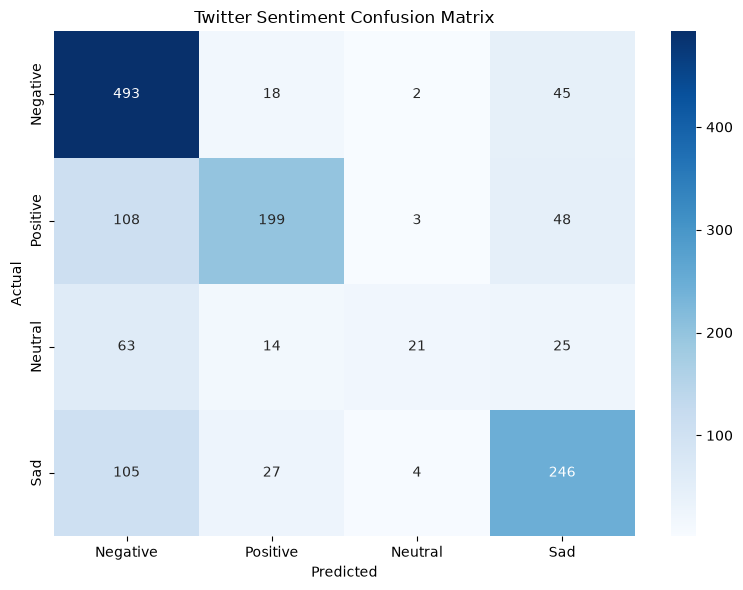

In [23]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. Harder task:
   - Amazon F1: ~0.83 | Twitter F1: ~0.58
   - Twitter is harder. Reviews are longer and clearer (people explain why they liked/disliked a product). Tweets are short, informal, use slang, sarcasm, and emojis get stripped out.

2. Character n-gram choices:
   - ngram_range=(2,5) because tweets have misspellings and abbreviations; character patterns still show up
   - Advantage over words: catches "luv", "gr8", hashtags, and partial words that word tokenizers would miss

3. Most confused class:
   - Neutral (label 2) gets confused the most, often predicted as negative or sad
   - Neutral/motivational tweets don't have strong polarity words, so the model picks nearby classes

4. Difficult tweet example:
   - Tweet: "great, just what I needed, another Monday"
   - Why it's hard: "great" sounds positive but the tone is sarcastic/negative. Without context the model sees positive words.

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [24]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")
arxiv = load_dataset("RimshaAIWizard/armanc_scientific_papers_arxiv_dataset")

# Sample from training set
arxiv_df = pd.DataFrame(arxiv['train']).sample(n=2000, random_state=42)

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset (this may take a moment)...


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

Loaded 2000 papers
Columns: ['article', 'abstract', 'section_names']


In [25]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
 spatial reciprocity is a well known tour de force of cooperation promotion . 
 a thorough understanding of the effects of different population densities is therefore crucial . here 
 we study the evolution of cooperation in social dilemmas on different interaction graphs with a certain fraction of vacant nodes . 
 we find that sparsity may favor the resolution of social dilemmas , especially if the population density is close to the percolation threshold of the underlying graph . 
 regardless o


In [26]:
import nltk
nltk.download('punkt_tab')
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# CountVectorizer for LDA (LDA expects word counts, not TF-IDF)
count_vec_arxiv = CountVectorizer(max_features=3000, min_df=5, max_df=0.9)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

[nltk_data] Downloading package punkt_tab to /Users/rawad/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Document-term matrix: (2000, 3000)


In [27]:
# 10 topics seems reasonable for physics/CS papers mix
n_topics_arxiv = 10

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers...


Done!


In [28]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: model, time, system, dark, parameter, result, data, method, dynamic, network, graph, oscillation
Topic 1: frequency, field, surface, effect, result, two, electron, phase, force, structure, using, optical
Topic 2: energy, neutrino, mass, xmath, decay, physic, model, quark, particle, data, collision, proton
Topic 3: quantum, state, system, phys, two, rev, interaction, cavity, photon, one, measurement, atom
Topic 4: xmath, spin, state, energy, band, magnetic, gap, fermi, topological, electron, phase, field
Topic 5: theory, field, equation, model, solution, wave, space, scalar, non, scale, mass, one
Topic 6: xmath, temperature, transition, phase, field, model, magnetic, critical, lattice, state, density, system
Topic 7: xmath, galaxy, star, ray, mass, source, emission, model, observation, cluster, disk, high
Topic 8: algorithm, error, method, code, problem, network, rate, performance, optimal, set, channel, based
Topic 9: xmath, xcite, function, value, on

### Exercise C.1: Interpret ArXiv Topics

In [29]:
# Labels based on top keywords from each LDA topic
my_arxiv_topic_labels = {
    0: "Machine Learning / Data Methods",
    1: "Condensed Matter Physics",
    2: "Particle Physics",
    3: "Quantum Systems",
    4: "Magnetism / Solid State",
    5: "Theoretical Physics",
    6: "Phase Transitions / Statistical Physics",
    7: "Astrophysics",
    8: "Algorithms / Computer Science",
    9: "Mathematical Methods",
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Machine Learning / Data Methods
  Topic 1: Condensed Matter Physics
  Topic 2: Particle Physics
  Topic 3: Quantum Systems
  Topic 4: Magnetism / Solid State
  Topic 5: Theoretical Physics
  Topic 6: Phase Transitions / Statistical Physics
  Topic 7: Astrophysics
  Topic 8: Algorithms / Computer Science
  Topic 9: Mathematical Methods


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [30]:
# Load legal contracts dataset (streaming to handle large size)
print("Loading Legal Contracts dataset...")
legal_stream = load_dataset("albertvillanova/legal_contracts", split="train", streaming=True, trust_remote_code=True)

# Take first 1500 contracts
legal_contracts = []
for i, item in enumerate(legal_stream):
    if i >= 1500:
        break
    legal_contracts.append(item)

legal_df = pd.DataFrame(legal_contracts)
print(f"Loaded {len(legal_df)} contracts")

Loading Legal Contracts dataset...


legal_contracts.py:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

Loaded 1500 contracts


In [31]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
quicklinks click rapidly navigate document amended restated employment noncompetition agreement amended restated employment noncompetition agreement agreement made entered october among avocent employment service formerly known polycon investment inc texas corporation employer avocent corporation de


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [32]:
# NMF works better with TF-IDF than raw counts for legal text
tfidf_legal = TfidfVectorizer(max_features=3000, min_df=5, max_df=0.95, ngram_range=(1, 2))

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1500, 3000)


In [33]:
# 8 topics covers main contract types (employment, lease, loans, etc.)
n_topics_legal = 8

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics...


Done!


In [34]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: executive, company, employment, shall, executive shall, agreement, salary, benefit, base salary, termination, base, bonus
Topic 1: borrower, loan, credit, lender, bank, credit agreement, agreement, agent, amendment, note, section, loan agreement
Topic 2: option, stock, share, plan, common stock, shall, common, company, stock option, exercise, optionee, granted
Topic 3: agreement, seller, buyer, purchase, shall, party, purchaser, product, amendment, section, share, closing
Topic 4: employee, employment, company, agreement, shall, employee shall, termination, employment agreement, bonus, salary, employee employment, employer
Topic 5: tenant, landlord, lease, rent, premise, lessee, building, lessor, shall, term, base rent, area
Topic 6: plan, participant, section, committee, award, compensation, article, retirement, mean, account, year, benefit
Topic 7: company, voting, change control, control, change, director, security, business combinatio

In [35]:
# Labels from NMF top words on legal contracts
my_legal_topic_labels = {
    0: "Executive Employment",
    1: "Loan / Credit Agreements",
    2: "Stock Options / Equity",
    3: "Purchase / Sales Contracts",
    4: "General Employment",
    5: "Lease / Real Estate",
    6: "Compensation / Retirement Plans",
    7: "Corporate Governance / M&A",
}

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Executive Employment
  Topic 1: Loan / Credit Agreements
  Topic 2: Stock Options / Equity
  Topic 3: Purchase / Sales Contracts
  Topic 4: General Employment
  Topic 5: Lease / Real Estate
  Topic 6: Compensation / Retirement Plans
  Topic 7: Corporate Governance / M&A


### Exercise C.3: Topic Distribution Visualization

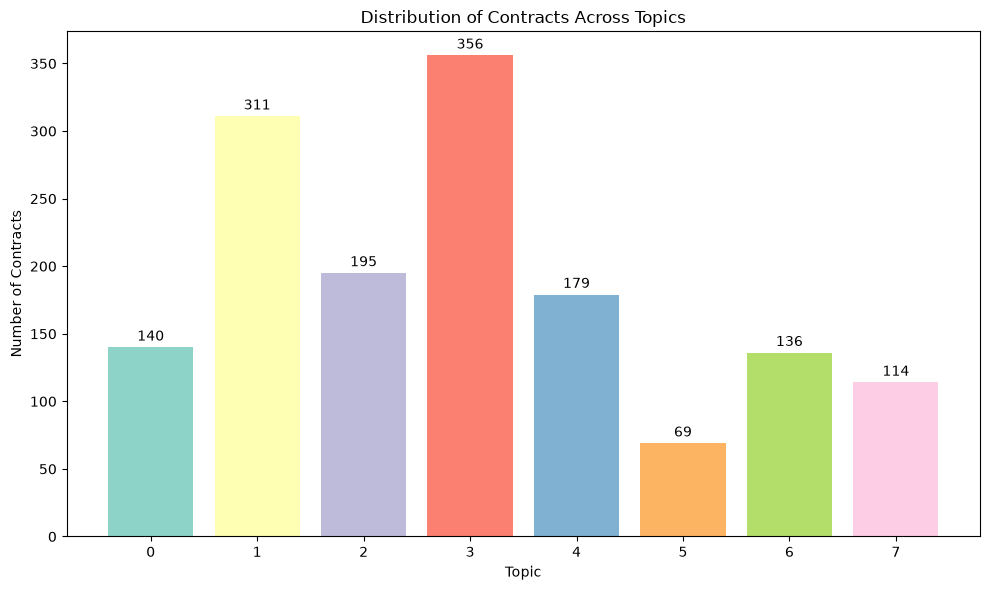

In [36]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. Easier to interpret:
   - Domain: ArXiv (LDA)
   - The topics had clear science keywords (quantum, galaxy, algorithm). Legal contracts all use similar formal language ("shall", "party", "agreement") so topics blur together more.

2. Legal topic distribution:
   - Not balanced. Purchase/sales (topic 3) has ~356 contracts, leases (topic 5) only ~69.
   - The dataset probably has more commercial contracts than real estate leases, or lease wording overlaps with other topics.

3. Topic refinement suggestions:
   - ArXiv - Merge: Topics 1 and 4 (both about physics/materials with overlapping terms like "field", "energy")
   - ArXiv - Split: Topic 9 (mixes math notation xmath with general terms) into pure math vs general methods
   - Legal - Merge: Topics 0 and 4 (both employment-related, one executive one general)
   - Legal - Split: Topic 3 (purchase/sales) because buyer-seller contracts differ a lot from service agreements

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
